# Quality-weighted ComBat - deep dive

`QualityWeightedComBat` replaces ComBat's unweighted per-batch moment estimates with weighted averages, where the weight is a non-negative scalar per sample (typically SNR). The shrinkage formula uses the **effective** (weighted) batch size, so batches dominated by low-quality samples shrink harder towards the prior.

This notebook fits both correctors, compares their posteriors, and sweeps across SNR regimes reporting three batch-mixing metrics.

Uses the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)); see notebook 01 for caching details.


## 1. MALDI-Kleb-AI SNR distribution


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from notebooks._demo import load_maldi_kleb_ai

ds = load_maldi_kleb_ai(antibiotic='Amikacin')
ds.quality.describe().round(2)

count    741.00
mean     112.70
std       65.54
min       19.37
25%       62.76
50%       99.10
75%      147.98
max      415.47
Name: SNR, dtype: float64

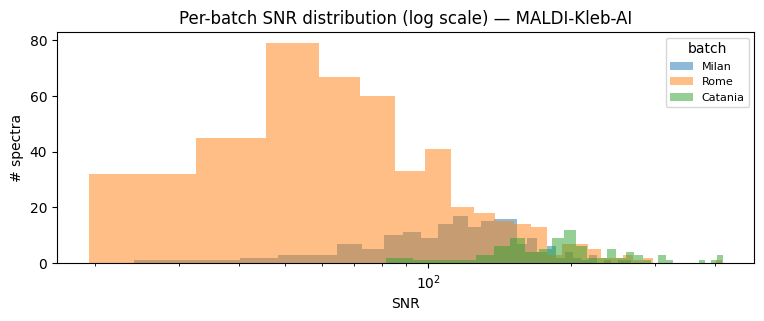

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(9, 3))
for lvl in ds.batch.unique():
    ax.hist(ds.quality[ds.batch == lvl], bins=30, alpha=0.5, label=lvl)
ax.set_xlabel('SNR')
ax.set_ylabel('# spectra')
ax.set_xscale('log')
ax.legend(title='batch', fontsize=8)
ax.set_title('Per-batch SNR distribution (log scale) - MALDI-Kleb-AI')
plt.show()

## 2. Fit both ComBat variants


In [3]:
from maldibatchkit import ComBat, QualityWeightedComBat

combat = ComBat(batch=ds.batch, method='johnson').fit(ds.X)
qw = QualityWeightedComBat(batch=ds.batch, quality=ds.quality).fit(ds.X)

X_combat = combat.transform(ds.X)
X_qw = qw.transform(ds.X)
print('QW-ComBat converged in', qw.n_iter_, 'iterations')

QW-ComBat converged in 3 iterations


## 3. Diagnostics side-by-side


In [4]:
from maldibatchkit.diagnostics import silhouette_batch, kbet, lisi

def metrics(X):
    return pd.Series({
        'silhouette': silhouette_batch(X, ds.batch),
        'kbet_acc': kbet(X, ds.batch, k=20)['acceptance_rate'],
        'lisi': lisi(X, ds.batch, perplexity=30.0),
    })

pd.concat(
    {'before': metrics(ds.X), 'ComBat': metrics(X_combat), 'QW-ComBat': metrics(X_qw)},
    axis=1,
).round(3)

,before,ComBat,QW-ComBat
silhouette,0.147,-0.011,0.009
kbet_acc,0.019,0.159,0.134
lisi,1.015,1.266,1.200


## 4. Effective batch sizes under quality weighting


In [5]:
pd.DataFrame({
    'raw_count': ds.batch.value_counts(),
    'effective_size_SNR_weighted': pd.Series(
        qw.effective_batch_sizes_, index=qw.batch_levels_
    ),
}).round(1)

,raw_count,effective_size_SNR_weighted
Catania,87,160.4
Milan,184,208.4
Rome,470,372.2


## 5. Posterior γ comparison


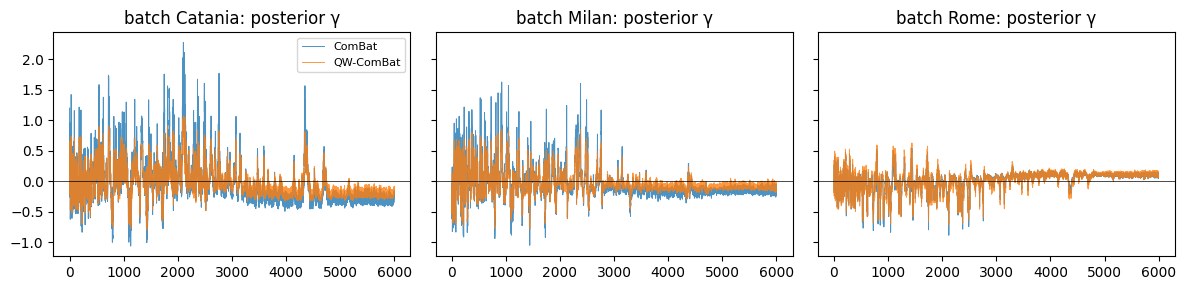

In [6]:
unw_gamma = combat._model._gamma_star  # (n_batches, n_features)
qw_gamma = qw.gamma_star_

fig, axes = plt.subplots(1, unw_gamma.shape[0], figsize=(4 * unw_gamma.shape[0], 3), sharey=True)
for i, (ax, lvl) in enumerate(zip(axes, qw.batch_levels_, strict=True)):
    ax.plot(unw_gamma[i], label='ComBat', alpha=0.8, lw=0.7)
    ax.plot(qw_gamma[i], label='QW-ComBat', alpha=0.8, lw=0.7)
    ax.set_title(f'batch {lvl}: posterior γ')
    ax.axhline(0.0, color='k', lw=0.5)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. SNR-quantile sensitivity


In [7]:
# How does QW-ComBat compare to ComBat on different SNR regimes?
# Report three batch-mixing metrics so we do not hang the conclusion
# on a single quantity.
import numpy as np

low = ds.quality < ds.quality.median()
high = ~low
regimes = [
    ('low-SNR half', low),
    ('high-SNR half', high),
    ('full', np.ones(len(ds.X), dtype=bool)),
]

rows = []
for label, mask in regimes:
    X_sub = ds.X.loc[mask]
    b_sub = ds.batch.loc[mask]
    q_sub = ds.quality.loc[mask]
    combat_s = ComBat(batch=b_sub).fit_transform(X_sub)
    qw_s = QualityWeightedComBat(batch=b_sub, quality=q_sub).fit_transform(X_sub)
    def _metrics(X, batch):
        return {
            'silhouette': silhouette_batch(X, batch),
            'kbet_acc':   kbet(X, batch, k=20)['acceptance_rate'],
            'lisi':       lisi(X, batch, perplexity=30.0),
        }
    combat_m = _metrics(combat_s, b_sub)
    qw_m     = _metrics(qw_s,     b_sub)
    rows.append({'regime': label, 'n': int(mask.sum()),
                 **{f'ComBat {k}':    combat_m[k] for k in combat_m},
                 **{f'QW-ComBat {k}': qw_m[k]     for k in qw_m}})
sweep = pd.DataFrame(rows).set_index('regime')
sweep.round(3)

/home/ettore/miniconda3/envs/metagenome/lib/python3.10/site-packages/sklearn/base.py:918: UserWarning: Batch sizes are highly imbalanced (ratio 107.0:1). Largest: 'Rome' (321 samples), smallest: 'Catania' (3 samples). Empirical Bayes estimates may be unreliable for small batches.
  return self.fit(X, **fit_params).transform(X)


,n,ComBat silhouette,ComBat kbet_acc,ComBat lisi,QW-ComBat silhouette,QW-ComBat kbet_acc,QW-ComBat lisi
regime,,,,,,,
low-SNR half,370,-0.126,0.719,1.067,-0.113,0.795,1.056
high-SNR half,371,-0.005,0.167,1.751,-0.001,0.170,1.742
full,741,-0.011,0.159,1.266,0.009,0.134,1.200
